In [1]:
library(cubature)
library(MASS)
library(pracma)
library(mvtnorm)

library(LogConcDEAD)
library(logcondens) 
library(mclust)
library(tensor)
library(RSpectra)

Warning message:
“no DISPLAY variable so Tk is not available”
Package 'mclust' version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.


Attaching package: ‘mclust’


The following object is masked from ‘package:mvtnorm’:

    dmvnorm




In [2]:
source('lcic.r')

## Functions to check

In [108]:
compute_directional_derivative_test <- function(Y_tst, SimData, W_current, estimator_current) {

    # Looks correct

    n <- SimData$n
    d <- SimData$d

    K_inds = matrix(0, nrow=n, ncol=d) # K_ij
    slopes_b = matrix(0, nrow=n, ncol=d)

    WY <- W_current %*% Y_tst
    grad_g_val <- 0

    for (dind in 1:d) {
        density <- estimator_current$marginals[[dind]]
        sample_sorting_indices <- estimator_current$sample_sorting_indices[[dind]]
        sorted_samples <- SimData$pre_data[sample_sorting_indices, ]
        mask <- (density$IsKnot == 1)
        cumsum_knots <- cumsum(density$IsKnot)
        slopes_knotwise <- diff(density$phi[mask])/diff(density$x[mask])
        
        num_knots <- sum(mask)
        knot_indices <- which(mask)
        c_vec <- WY[dind,]
        transformed_samples <- sorted_samples %*% c_vec
        selection_indicators <- transformed_samples[mask] 

        K_inds[,dind] = cumsum_knots # handles most points correctly
        K_inds[knot_indices, dind] <- ifelse(selection_indicators<0, c(1:num_knots)-1, c(1:num_knots)) # corrects the knot points

        K_inds[1, dind] <- 1
        K_inds[n, dind] <- num_knots - 1 # corrects the first and the last knot points

        slopes_b[,dind] <- slopes_knotwise[K_inds[,dind]]

        grad_g_val <- grad_g_val + sum(transformed_samples*slopes_b[,dind])/n
    }
    return(list("grad_g_val"=grad_g_val, "slopes_b"=slopes_b))
}

compute_normalized_log_likelihood_g_test <- function(SimData, W_candidate, estimator_current) {

    # Looks correct, but check in a notebook! Test against alternative comparisons?
    # Compare with the likelihood value computed by the logConDens function?

    g_val <- 0

    Z_mat_candidate <- SimData$pre_data %*% t(W_candidate)

    for (dind in 1:SimData$d) {
        
        g_val <- g_val + (1/SimData$n)*sum(evaluateLogConDens(Z_mat_candidate[,dind], estimator_current$marginals[[dind]], which=1)[,2])
    }
    return(g_val)
}

update_W_given_marginals_test <- function(SimData, W_current, estimator_current, alp=0.3, gmm=0.5) {

    # Find steepest descent along the basis of the tangent space
    Y_tst <- matrix(0, nrow=SimData$d, ncol=SimData$d)
    grad_g_vals <- matrix(0, nrow=SimData$d, ncol=SimData$d)

    for (s in 1:(SimData$d - 1)){
        for (r in (s+1):SimData$d) {
            Y_tst[r,s] <- 1/sqrt(2)
            Y_tst[s,r] <- -1/sqrt(2)
            grad_g_vals[r,s] <- compute_directional_derivative(Y_tst, SimData, W_current, estimator_current)
            grad_g_vals[s,r] <- compute_directional_derivative(-Y_tst, SimData, W_current, estimator_current)
            Y_tst[r,s] <- 0
            Y_tst[s,r] <- 0
        }
    }
    grad_g_max <- max(grad_g_vals)
    max_inds <- which(grad_g_vals == grad_g_max, arr.ind = TRUE)
    r_max <- max_inds[1,1]
    s_max <- max_inds[1,2]

    # Construct Y_max
    Y_max <- matrix(0, nrow=SimData$d, ncol=SimData$d)
    Y_max[r_max,s_max] <- 1/sqrt(2)
    Y_max[s_max, r_max] <- -1/sqrt(2)

    # Line search
    ep <- 1.0
    W_candidate_update <- W_current %*% expm(ep*Y_max)
    g_val_current <- compute_normalized_log_likelihood_g(SimData, W_current, estimator_current)
    g_val_update <- compute_normalized_log_likelihood_g(SimData, W_candidate_update, estimator_current)
    counter <- 0

    cat("g_val_current: ", g_val_current, "\n")
    cat("g_val_update: ", g_val_update, "\n")
    while (g_val_update <= g_val_current + alp*ep*grad_g_max) {
        
        ep <- gmm*ep
        W_candidate_update <- W_current %*% expm(ep*Y_max)
        g_val_update <- compute_normalized_log_likelihood_g(SimData, W_candidate_update, estimator_current)

        cat("Counter: ", counter, "\n")
        cat("grad: ", grad_g_max, "\n")
        cat("g_val_update: ", g_val_update, "\n")
        
        counter <- counter + 1
        if (counter > 20) break
    }  
    return(W_candidate_update)
}



In [95]:
# cat("Counter: ", 4)


Counter:  4

In [13]:
point_alpha = 1.0

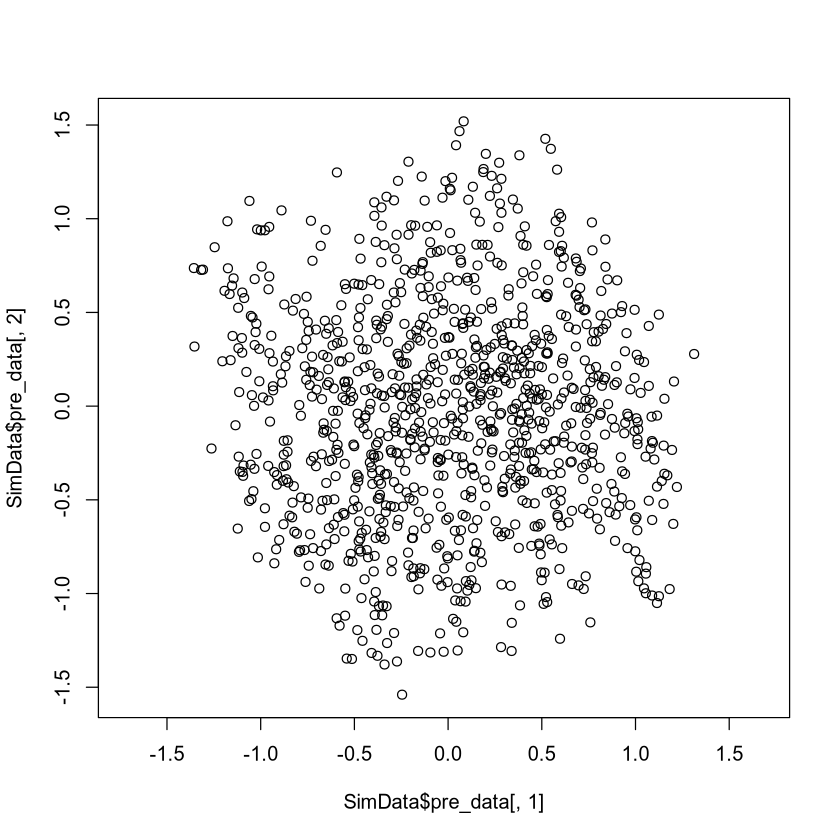

In [119]:
# Generate data

d = 4
n = 1000
true_mean_vec <- rep(0,d) 
scalings_vec = rep(1, d)
W <- fix_signs_fun(randortho(d, type="orthonormal"))
SimData <- get_uniform_data(d, n, true_mean_vec, scalings_vec=scalings_vec, W=W)

plot(x=SimData$pre_data[,1], y=SimData$pre_data[,2], asp=1)


### Checking directional derivative computations

In [120]:
W_current = fix_signs_fun(randortho(d, type="orthonormal"))

# W_guess - SimData$W

estimator_current <- fit_marginals_given_W(SimData, W_current, plotting=FALSE)

[1] "Marginal: "
[1] 1
[1] "Marginal: "
[1] 2
[1] "Marginal: "
[1] 3
[1] "Marginal: "
[1] 4


In [77]:
Y_tst <- matrix(0, nrow=SimData$d, ncol=SimData$d)
r <- 2
s <- 1
Y_tst[r,s] <- 1/sqrt(2)
Y_tst[s,r] <- -1/sqrt(2)

Y_tst <- -Y_tst

outlist <- compute_directional_derivative_test(Y_tst, SimData, W_current, estimator_current)

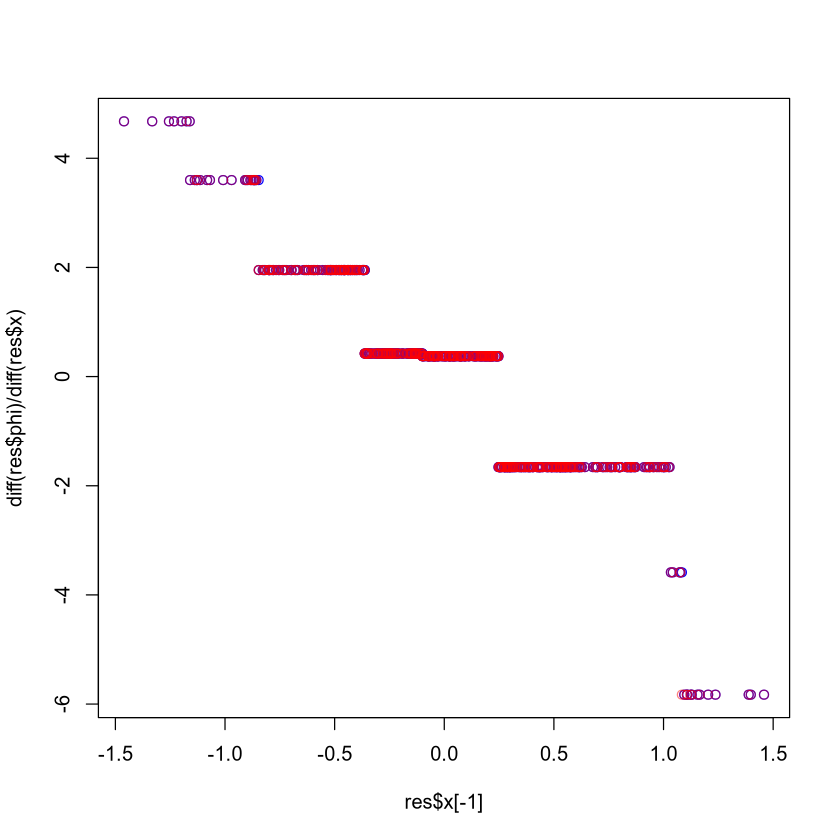

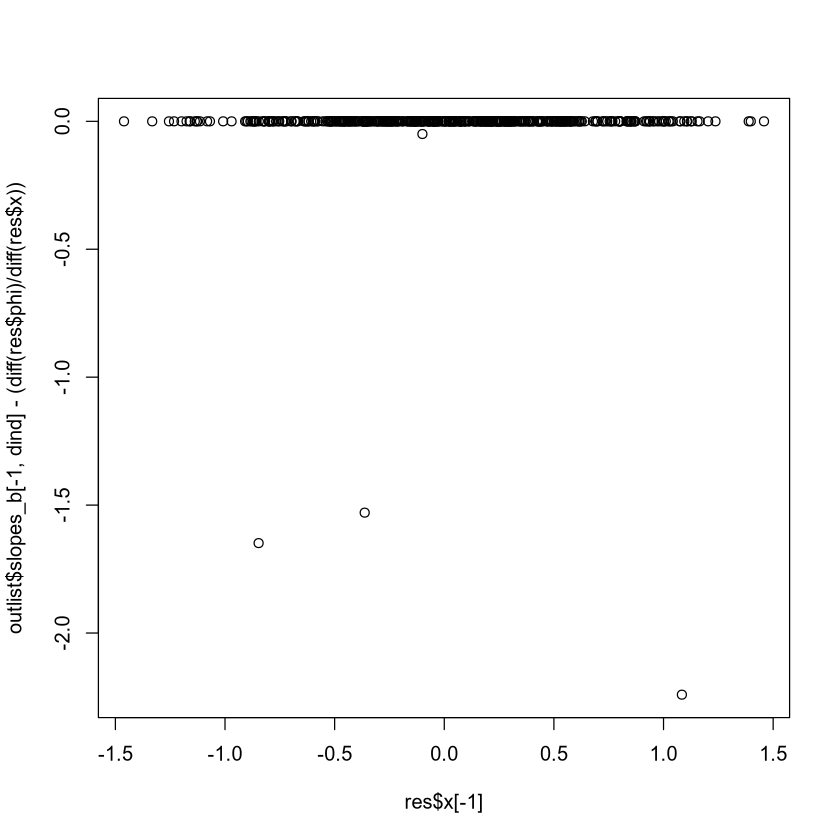

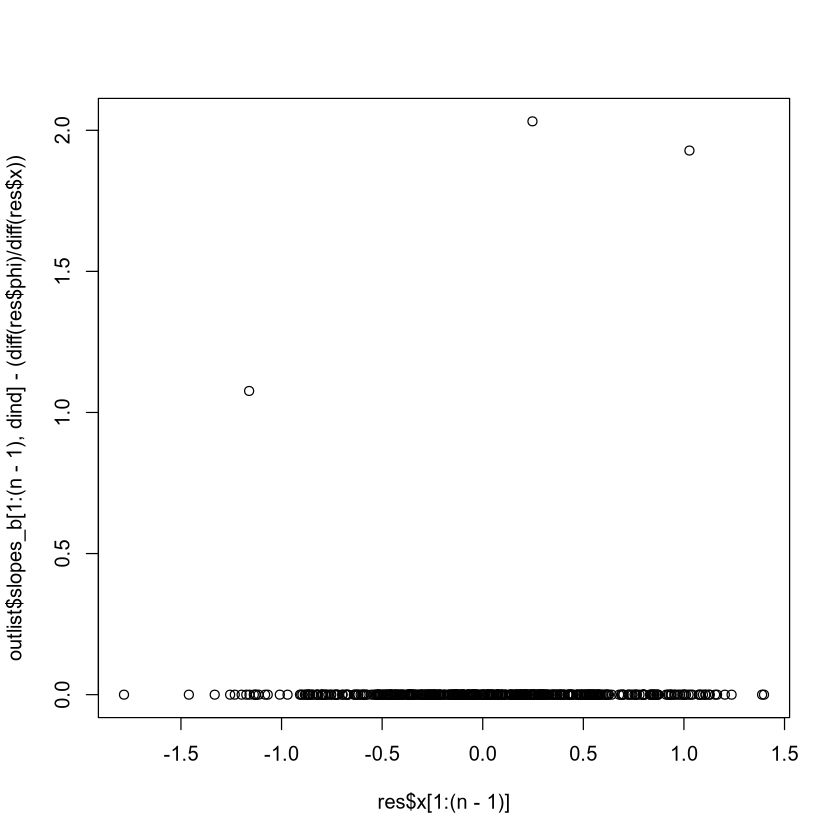

In [85]:
dind = 1

res <- estimator_current$marginals[[dind]]
plot(res$x[-1], diff(res$phi) / diff(res$x), col=rgb(0,0,1,point_alpha))

points(res$x, outlist$slopes_b[,dind], col=rgb(1,0,0,0.5))

plot(res$x[-1], outlist$slopes_b[-1,dind] - (diff(res$phi)/diff(res$x)))

plot(res$x[1:(n-1)], outlist$slopes_b[1:(n-1),dind] - (diff(res$phi)/diff(res$x)))

# plot(outlist$selection_indicators) # We weren't saving for both marginals!

In [89]:
# print(Y_tst)
# print(max(Y_tst))
# which(Y_tst == max(Y_tst), arr.ind=TRUE)
tstvec = c(1,3,5,7)
tstvec[1:3]
tstvec[-1]

[1] 1 3 5

[1] 3 5 7

### Checking likelihood computations

In [112]:
# estimator_current <- fit_marginals_given_W(SimData, W_current, plotting=FALSE)

likelihood_val = compute_normalized_log_likelihood_g_test(SimData, W_current, estimator_current)
print(likelihood_val)

[1] -1.307679


In [113]:
# Alternative likelohood computations to cross-verify

L_val = 0

for (dind in 1:d) {

    density <- estimator_current$marginals[[dind]]

    L_val <- L_val + density$L + 1
    
}

L_val


[1] -1.307679

In [114]:
likelihood_val - L_val

[1] 0

In [122]:
alp=0.3 
gmm=0.1
W_new <- update_W_given_marginals_test(SimData, W_current, estimator_current, alp=alp, gmm=gmm)

g_val_current:  -3.425427 
g_val_update:  -Inf 
Counter:  0 
grad:  0.1003024 
g_val_update:  -Inf 
Counter:  1 
grad:  0.1003024 
g_val_update:  -Inf 
Counter:  2 
grad:  0.1003024 
g_val_update:  -Inf 
Counter:  3 
grad:  0.1003024 
g_val_update:  -Inf 
Counter:  4 
grad:  0.1003024 
g_val_update:  -Inf 
Counter:  5 
grad:  0.1003024 
g_val_update:  -Inf 
Counter:  6 
grad:  0.1003024 
g_val_update:  -Inf 
Counter:  7 
grad:  0.1003024 
g_val_update:  -3.425427 
Counter:  8 
grad:  0.1003024 
g_val_update:  -3.425427 
Counter:  9 
grad:  0.1003024 
g_val_update:  -3.425427 
Counter:  10 
grad:  0.1003024 
g_val_update:  -3.425427 
Counter:  11 
grad:  0.1003024 
g_val_update:  -3.425427 
Counter:  12 
grad:  0.1003024 
g_val_update:  -3.425427 
Counter:  13 
grad:  0.1003024 
g_val_update:  -3.425427 
Counter:  14 
grad:  0.1003024 
g_val_update:  -3.425427 
Counter:  15 
grad:  0.1003024 
g_val_update:  -3.425427 
Counter:  16 
grad:  0.1003024 
g_val_update:  -3.425427 
Counter:  1